# Brodmann Labels on ICBM152 and Colin27

This notebook starts from the Brodmann Mai-Matajnik atlas (`Brodmann_Mai_Matajnik.nii`) and a Brodmann label JSON lookup. It assigns the atlas labels to brain-surface vertices with `TwoSurfaceHeadModel.assign_parcels_via_mni_coords`, plots the result, and optionally saves compact parcel-level TSV summaries at the end.

In [66]:
from pathlib import Path
import json
import cedalion.data
import cedalion.dot
import cedalion.vis.blocks as vbx
import numpy as np
import pandas as pd
import pyvista as pv
from scipy.spatial import KDTree

pv.set_jupyter_backend("static")

In [67]:
brodmann_files = cedalion.data.get_brodmann_atlas_files()
BROD_DIR = brodmann_files.basedir
BROD_NII = brodmann_files.nifti
BROD_LABEL_JSON = brodmann_files.labels_json

# Write generated summary tables to the current working directory.
OUTPUT_DIR = Path(r"C:\Users\mayucel\Documents\CODE\atlas")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
SAVE_PARCEL_SUMMARY_TSVS = True
OUT_COLIN_PARCEL_SUMMARY_TSV = OUTPUT_DIR / "brodmann_parcel_summary_colin27.tsv"
OUT_ICBM_PARCEL_SUMMARY_TSV = OUTPUT_DIR / "brodmann_parcel_summary_icbm152.tsv"

for path in [BROD_NII, BROD_LABEL_JSON]:
    if not path.exists():
        raise FileNotFoundError(path)

BROD_NII


WindowsPath('C:/Users/mayucel/Documents/GitHub/cedalion/src/cedalion/data/atlases/brodmann/Brodmann_Mai_Matajnik.nii')

## Load Brodmann Label Names

The bundled Brodmann JSON uses the same top-level structure as the AAL lookup: metadata plus a `labels` list with `index` and `name`.


In [68]:
with BROD_LABEL_JSON.open("r", encoding="utf-8") as fin:
    brod_info = json.load(fin)

brod_label_mapping = {0: "Background"}
brod_label_mapping.update({int(item["index"]): item["name"] for item in brod_info["labels"]})

print(f"Loaded {len(brod_info['labels'])} Brodmann labels from {BROD_LABEL_JSON.name}.")


Loaded 86 Brodmann labels from brodmann_labels.json.


## Assign Brodmann Atlas onto ICBM152 Surface

In [69]:
head_icbm = cedalion.dot.get_standard_headmodel("icbm152")
head_icbm_brodmann_raw = head_icbm.assign_parcels_via_mni_coords(
    "parcel_brodmann",
    brod_label_mapping,
    BROD_NII,
    voxel_label_crs="mni152",
    mni_eps=5.0,
)
coords_mni = head_icbm.get_brain_mni152_coords().pint.dequantify()
vertex = coords_mni.label.values

brodmann_labels = head_icbm_brodmann_raw.brain.vertices.coords["parcel_brodmann"].values

df_brod_icbm = pd.DataFrame({
    "vertex": vertex,
    "model": "icbm152",
    "source_nifti": str(BROD_NII),
    "x": coords_mni.values[:, 0],
    "y": coords_mni.values[:, 1],
    "z": coords_mni.values[:, 2],
    "brodmann_name": brodmann_labels,
})

print(f"ICBM152 Brodmann vertex labels: {len(df_brod_icbm)} vertices, {df_brod_icbm['brodmann_name'].nunique()} unique labels.")
print(f"Background vertices: {int(df_brod_icbm['brodmann_name'].eq('Background').sum())}")

ICBM152 Brodmann vertex labels: 25000 vertices, 87 unique labels.
Background vertices: 1096


## Plot Brodmann Labels on ICMB152

ICBM152 background vertices: 1096 raw -> 0 plotted


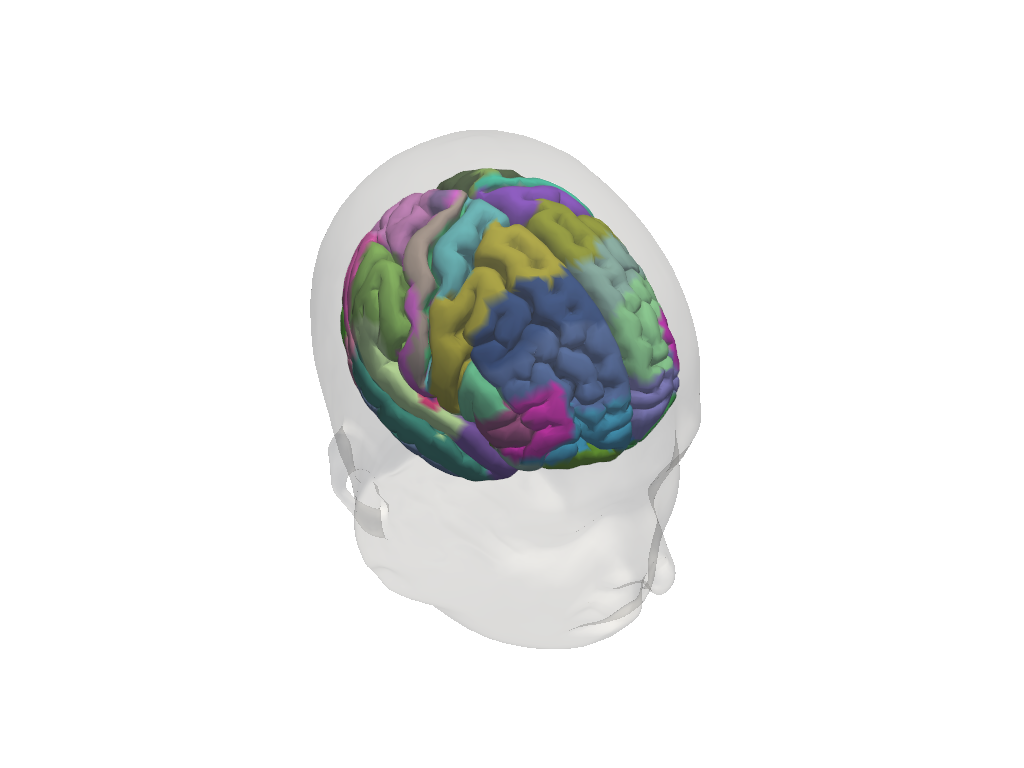

In [70]:
def make_label_colors(names):
    unique_names = sorted(name for name in pd.unique(names) if name != "Background")
    rng = np.random.default_rng(42)
    colors = {name: rng.integers(30, 255, size=3).astype(np.uint8).tolist() for name in unique_names}
    colors["Background"] = [235, 235, 235]
    return colors


brod_colors = make_label_colors(df_brod_icbm["brodmann_name"])


def fill_background_from_nearest_surface_label(df, head):
    df_filled = df.sort_values("vertex").copy()
    background = df_filled["brodmann_name"].eq("Background")
    if not background.any():
        return df_filled

    vertices = head.brain.vertices.pint.dequantify()
    coords = vertices.sel(label=df_filled["vertex"].to_numpy()).values
    labeled = ~background.to_numpy()
    _, nearest = KDTree(coords[labeled]).query(coords[~labeled])

    labeled_rows = df_filled.loc[labeled]
    background_rows = df_filled.index[~labeled]
    nearest_rows = labeled_rows.iloc[nearest]
    df_filled.loc[background_rows, "brodmann_name"] = nearest_rows["brodmann_name"].to_numpy()
    return df_filled


def colors_for_vertices(df):
    df = df.sort_values("vertex")
    return np.asarray([brod_colors[name] for name in df["brodmann_name"].values], dtype=np.uint8)


df_brod_icbm_plot = fill_background_from_nearest_surface_label(df_brod_icbm, head_icbm)
print(
    "ICBM152 background vertices:",
    int(df_brod_icbm["brodmann_name"].eq("Background").sum()),
    "raw ->",
    int(df_brod_icbm_plot["brodmann_name"].eq("Background").sum()),
    "plotted",
)
colors_icbm_brod = colors_for_vertices(df_brod_icbm_plot)

plt = pv.Plotter()
vbx.plot_surface(plt, head_icbm.scalp, color="w", opacity=.2)
vbx.plot_surface(plt, head_icbm.brain, color=colors_icbm_brod)
plt.show()

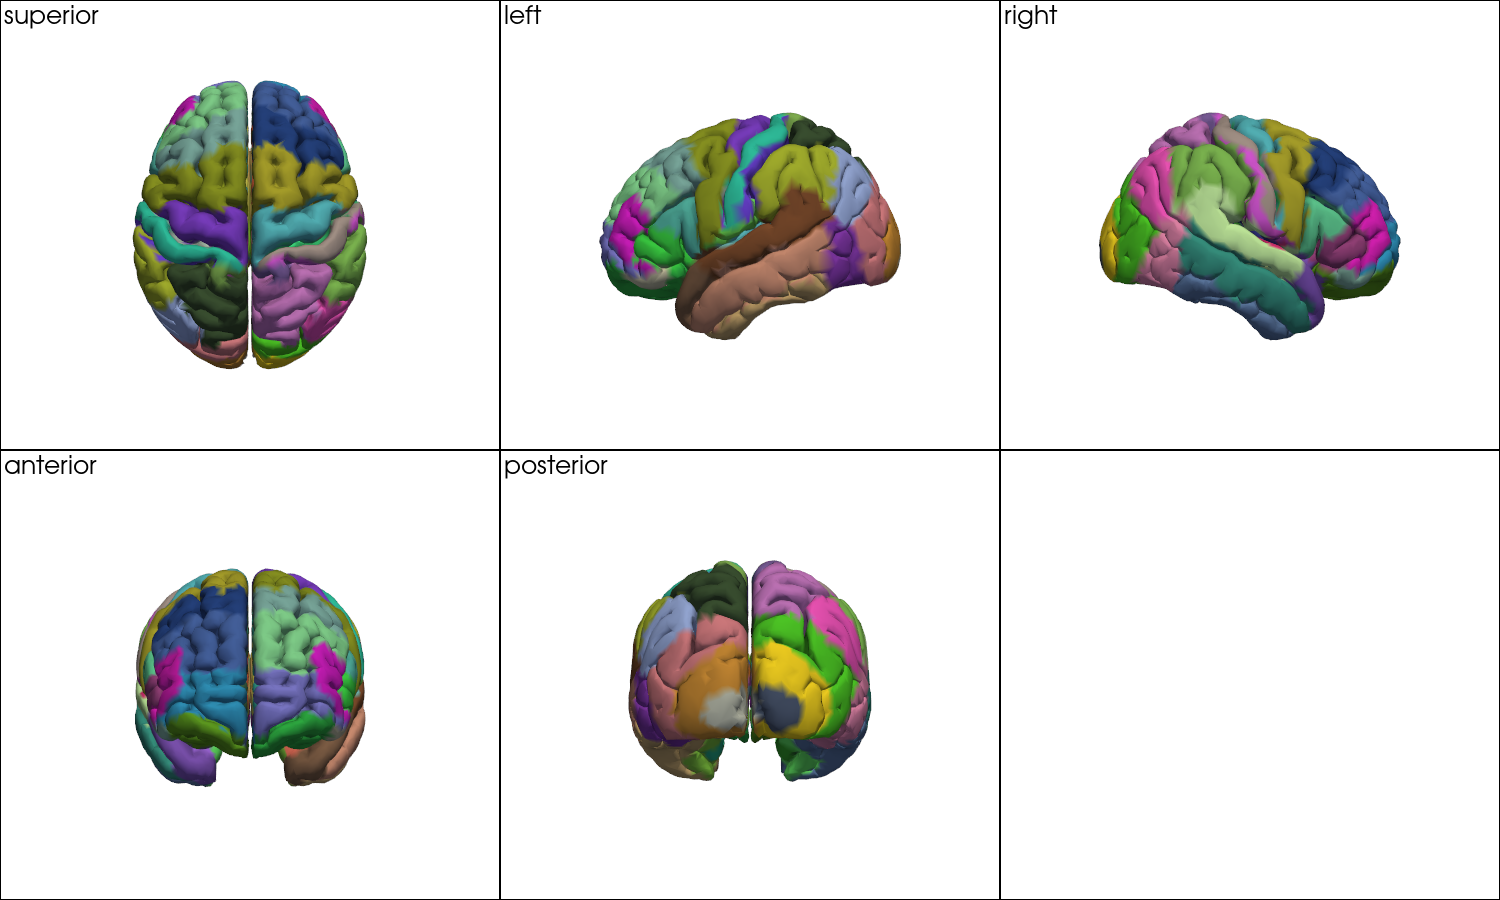

In [71]:
def camera_for_view(center, view, distance=360):
    cameras = {
        "superior": ([0, 0, distance], [0, 1, 0]),
        "left": ([-distance, 0, 0], [0, 0, 1]),
        "right": ([distance, 0, 0], [0, 0, 1]),
        "anterior": ([0, distance, 0], [0, 0, 1]),
        "posterior": ([0, -distance, 0], [0, 0, 1]),
    }
    position_offset, up = cameras[view]
    return center + np.asarray(position_offset), center, up


def plot_brain_views_grid(head, colors, views=("superior", "left", "right", "anterior", "posterior")):
    brain_center = head.brain.vertices.pint.dequantify().mean("label").values
    plt = pv.Plotter(shape=(2, 3), window_size=(1500, 900))
    positions = [(0, 0), (0, 1), (0, 2), (1, 0), (1, 1)]
    for view, subplot in zip(views, positions):
        plt.subplot(*subplot)
        vbx.plot_surface(plt, head.brain, color=colors)
        plt.add_text(view, font_size=10)
        plt.camera.position, plt.camera.focal_point, plt.camera.up = camera_for_view(brain_center, view)
        plt.reset_camera()
    plt.subplot(1, 2)
    plt.add_text("", font_size=10)
    plt.show()


plot_brain_views_grid(head_icbm, colors_icbm_brod)


def plot_surface_views_grid(surface, colors, views=("superior", "left", "right", "anterior", "posterior")):
    surface_center = surface.vertices.pint.dequantify().mean("label").values
    plt = pv.Plotter(shape=(2, 3), window_size=(1500, 900))
    positions = [(0, 0), (0, 1), (0, 2), (1, 0), (1, 1)]
    for view, subplot in zip(views, positions):
        plt.subplot(*subplot)
        vbx.plot_surface(plt, surface, color=colors)
        plt.add_text(view, font_size=10)
        plt.camera.position, plt.camera.focal_point, plt.camera.up = camera_for_view(surface_center, view)
        plt.reset_camera()
    plt.subplot(1, 2)
    plt.add_text("", font_size=10)
    plt.show()

def add_brodmann_vertex_coordinate(head, df, coord_name="parcel_brodmann"):
    hm = head.copy()
    df_sorted = df.sort_values("vertex")
    hm.brain.vertex_coords[coord_name] = df_sorted["brodmann_name"].to_numpy()
    return hm



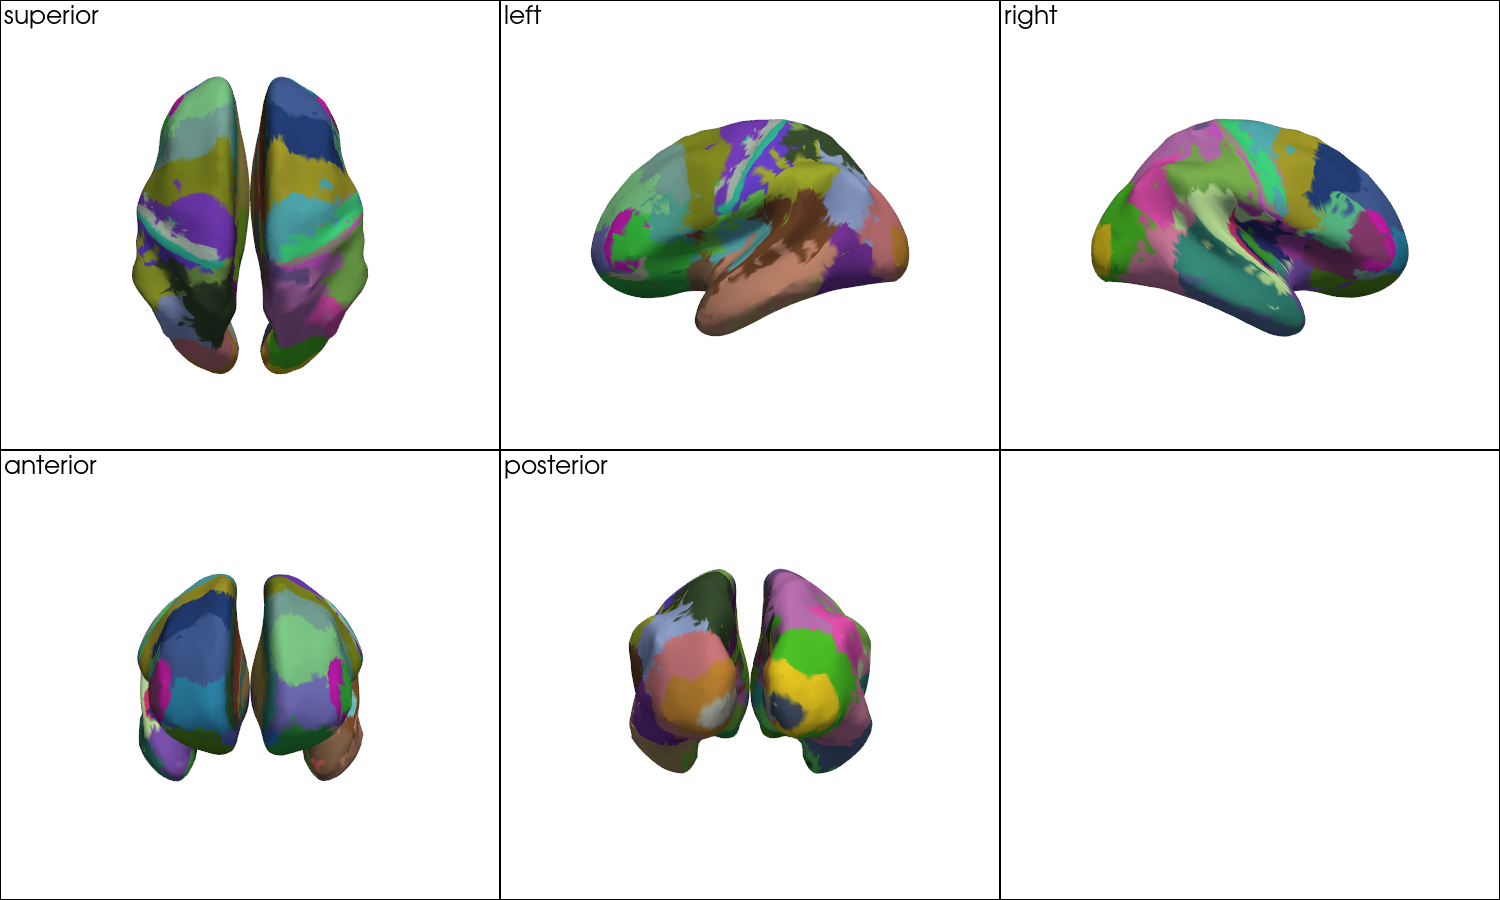

In [72]:
infl_icbm = cedalion.dot.get_inflated_cortex_surface("icbm152")
plot_surface_views_grid(infl_icbm, colors_icbm_brod)

## Highlight an ROI On ICBM152

This example highlights BA44 and BA45 on the ICBM152 pial and inflated cortex.

Plotting right_BA44 + right_BA45 on icbm152 (561 vertices).


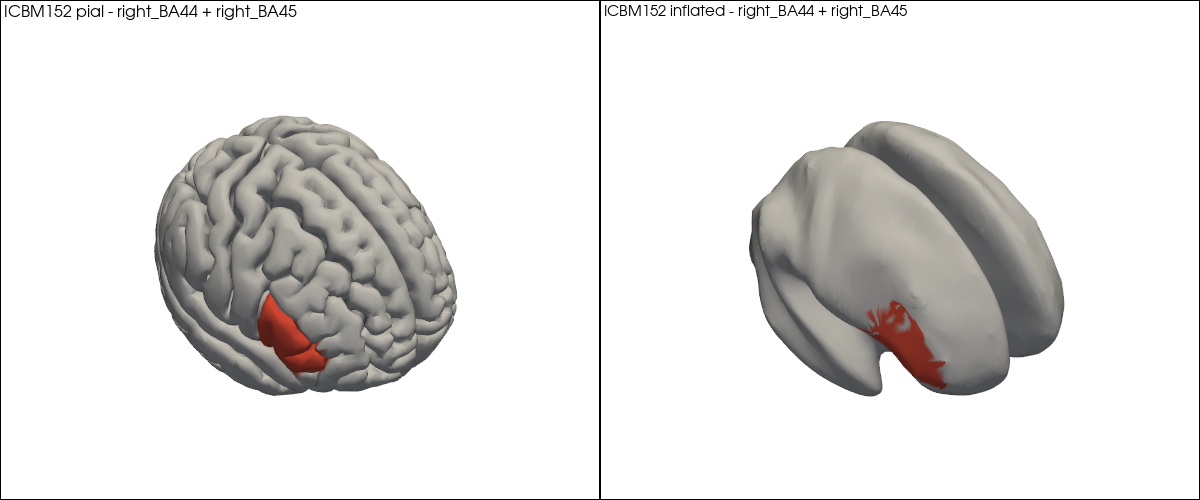

In [73]:
target_brodmann = ["right_BA44", "right_BA45"]


def colors_for_single_brodmann_roi(df, roi_names, roi_color=(230, 80, 60), background=(210, 210, 210)):
    df_sorted = df.sort_values("vertex")
    if isinstance(roi_names, str):
        roi_names = [roi_names]
    roi_names = list(roi_names)

    available_names = set(df_sorted["brodmann_name"])
    missing = [name for name in roi_names if name not in available_names]
    if missing:
        suggestions = {
            name: sorted(candidate for candidate in available_names if name.lower() in candidate.lower())[:10]
            for name in missing
        }
        raise ValueError(f"Unknown Brodmann ROI(s) {missing}. Suggestions: {suggestions}")

    roi_names = set(roi_names)
    return np.asarray(
        [roi_color if name in roi_names else background for name in df_sorted["brodmann_name"].values],
        dtype=np.uint8,
    )


target_label = " + ".join(target_brodmann)
single_roi_colors_icbm = colors_for_single_brodmann_roi(df_brod_icbm_plot, target_brodmann)
vertex_count = int(df_brod_icbm_plot["brodmann_name"].isin(target_brodmann).sum())
print(f"Plotting {target_label} on icbm152 ({vertex_count} vertices).")

infl_icbm = cedalion.dot.get_inflated_cortex_surface("icbm152")
plt = pv.Plotter(shape=(1, 2), window_size=(1200, 500))

plt.subplot(0, 0)
plt.add_text(f"ICBM152 pial - {target_label}", position="upper_left", font_size=10)
vbx.plot_surface(plt, head_icbm.brain, color=single_roi_colors_icbm)

plt.subplot(0, 1)
plt.add_text(f"ICBM152 inflated - {target_label}", position="upper_left", font_size=10)
vbx.plot_surface(plt, infl_icbm, color=single_roi_colors_icbm)

plt.show()

## ICBM152 Brain Vertices with Brodmann Coordinate

This mirrors the `assign_parcels_via_mni_coords` example output: the Brodmann label is added as a vertex coordinate, then the xarray `DataArray` is displayed directly.


In [74]:
head_icbm_brodmann = add_brodmann_vertex_coordinate(head_icbm, df_brod_icbm_plot)
head_icbm_brodmann.brain.vertices


Magnitude,[[81.244216 26.627602 150.621031] [81.577181 27.302513 157.143576] [77.826448 27.459724 154.566914] ... [118.580717 84.619659 208.0373] [143.100407 63.906384 138.08789] [133.577629 151.8062 150.919106]]
Units,dimensionless


## Plot Brodmann Labels On Colin27 via Approximation

The Brodmann atlas is assigned directly to Colin27 with `assign_parcels_via_mni_coords`, using the same label mapping as ICBM152.

In [75]:
def brodmann_vertex_dataframe(head_labeled, model, source_nifti):
    coords_mni = head_labeled.get_brain_mni152_coords().pint.dequantify()
    return pd.DataFrame({
        "vertex": head_labeled.brain.vertices.label.values,
        "model": model,
        "coordinate_mode": "assign_parcels_via_mni_coords",
        "source_nifti": str(source_nifti),
        "x": coords_mni.values[:, 0],
        "y": coords_mni.values[:, 1],
        "z": coords_mni.values[:, 2],
        "brodmann_name": head_labeled.brain.vertices.coords["parcel_brodmann"].values,
    })


head_colin = cedalion.dot.get_standard_headmodel("colin27")
head_colin_brodmann_raw = head_colin.assign_parcels_via_mni_coords(
    "parcel_brodmann",
    brod_label_mapping,
    BROD_NII,
    voxel_label_crs="mni152",
    mni_eps=5.0,
)
df_brod_colin_raw = brodmann_vertex_dataframe(head_colin_brodmann_raw, "colin27", BROD_NII)
df_brod_colin = fill_background_from_nearest_surface_label(df_brod_colin_raw, head_colin)
print(
    "Colin27 approximate Brodmann background vertices:",
    int(df_brod_colin_raw["brodmann_name"].eq("Background").sum()),
    "raw ->",
    int(df_brod_colin["brodmann_name"].eq("Background").sum()),
    "plotted",
)
print(f"Colin27 Brodmann vertex labels: {len(df_brod_colin)} vertices, {df_brod_colin['brodmann_name'].nunique()} unique labels.")

Colin27 approximate Brodmann background vertices: 1025 raw -> 0 plotted
Colin27 Brodmann vertex labels: 25000 vertices, 86 unique labels.


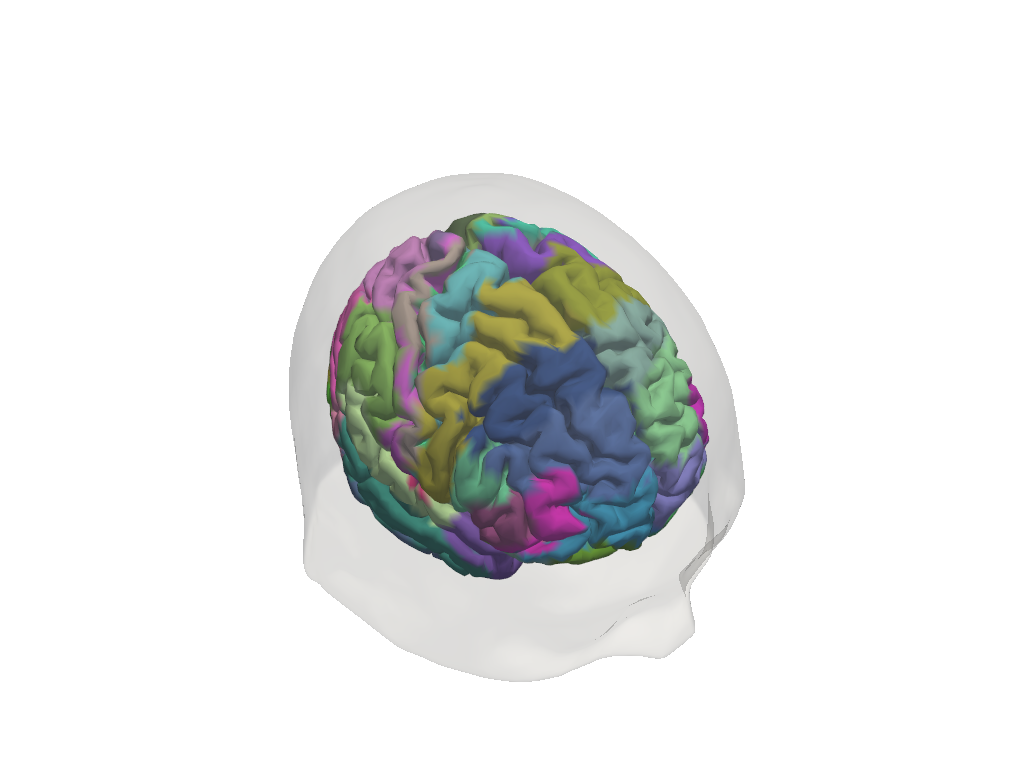

In [76]:
colors_colin_brod = colors_for_vertices(df_brod_colin)

plt = pv.Plotter()
vbx.plot_surface(plt, head_colin.scalp, color="w", opacity=.2)
vbx.plot_surface(plt, head_colin.brain, color=colors_colin_brod)
plt.show()

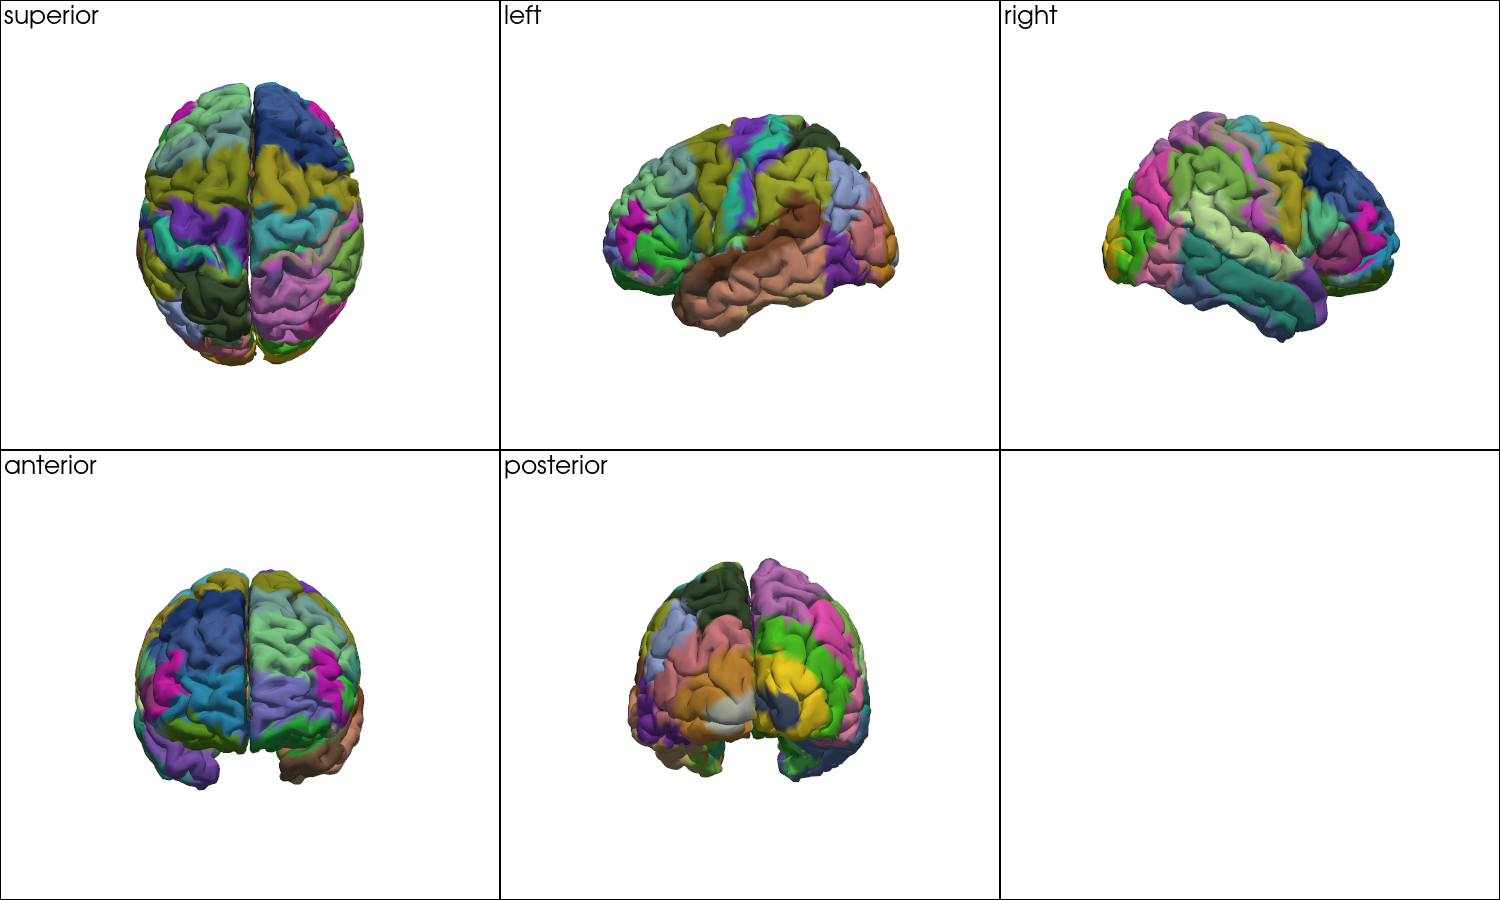

In [77]:
plot_brain_views_grid(head_colin, colors_colin_brod)

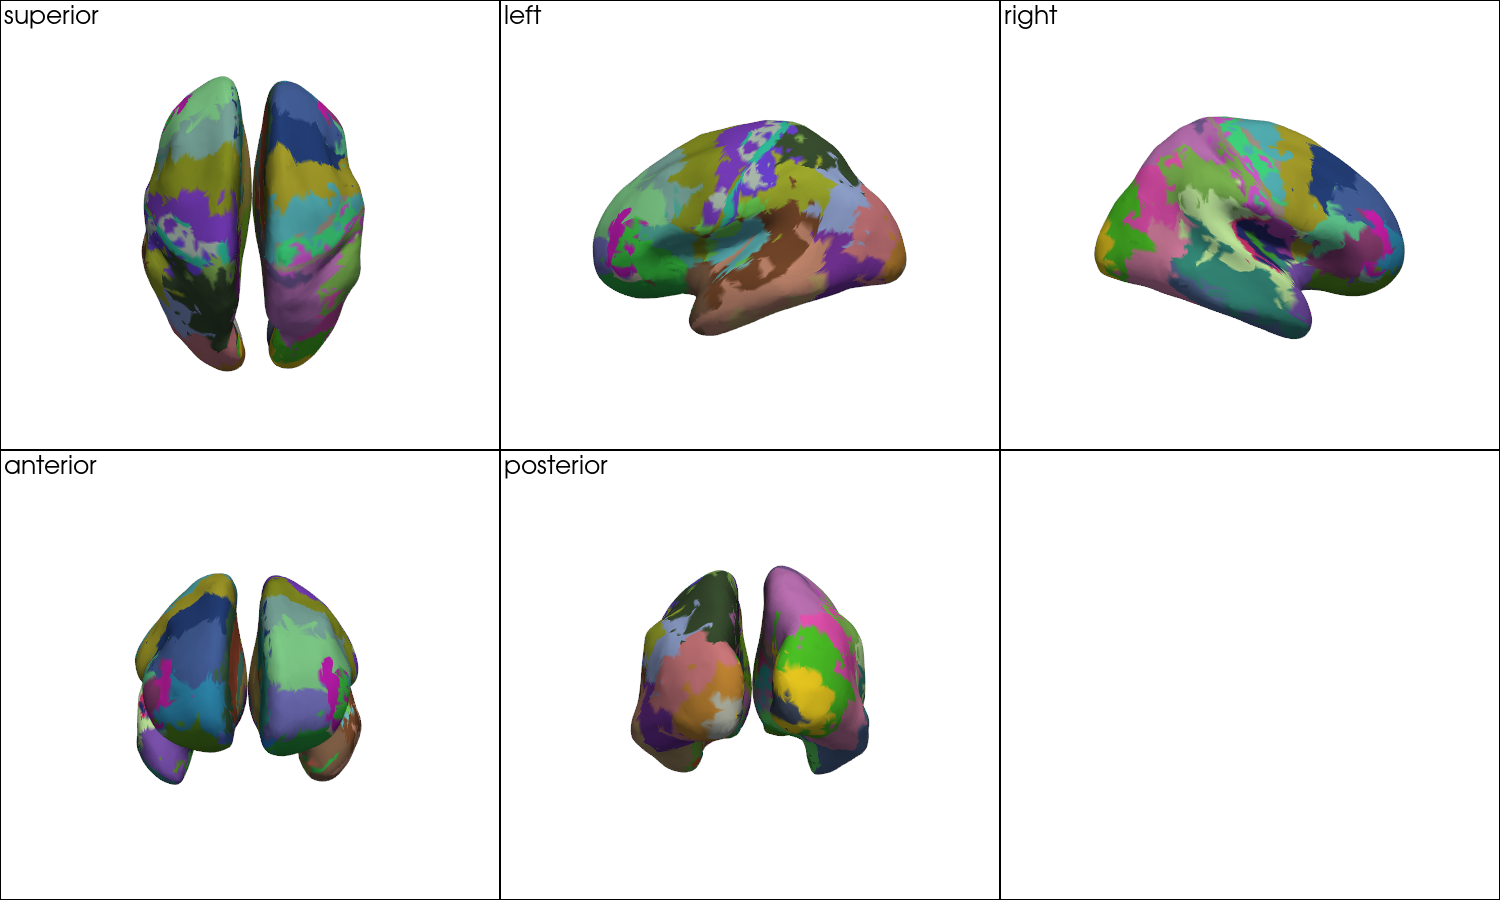

In [78]:
infl_colin = cedalion.dot.get_inflated_cortex_surface("colin27")
plot_surface_views_grid(infl_colin, colors_colin_brod)

## Highlight an on Colin27

This example highlights the same BA44 and BA45 labels after transferring the Brodmann approximation to the Colin27 pial and inflated cortex.

Plotting right_BA44 + right_BA45 on colin27 (510 vertices).


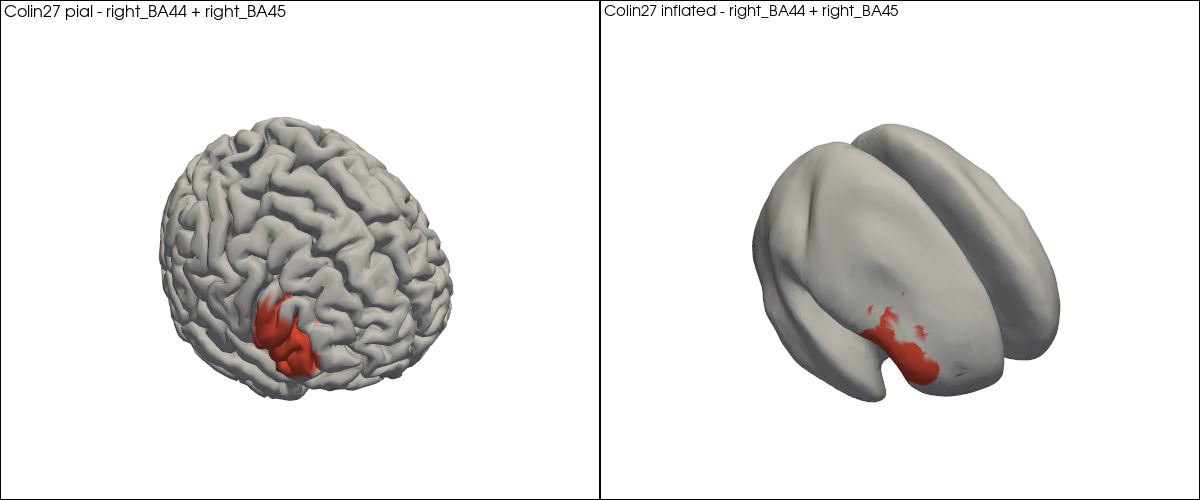

In [79]:
target_label = " + ".join(target_brodmann)
single_roi_colors_colin = colors_for_single_brodmann_roi(df_brod_colin, target_brodmann)
vertex_count = int(df_brod_colin["brodmann_name"].isin(target_brodmann).sum())
print(f"Plotting {target_label} on colin27 ({vertex_count} vertices).")

plt = pv.Plotter(shape=(1, 2), window_size=(1200, 500))

plt.subplot(0, 0)
plt.add_text(f"Colin27 pial - {target_label}", position="upper_left", font_size=10)
vbx.plot_surface(plt, head_colin.brain, color=single_roi_colors_colin)

plt.subplot(0, 1)
plt.add_text(f"Colin27 inflated - {target_label}", position="upper_left", font_size=10)
vbx.plot_surface(plt, infl_colin, color=single_roi_colors_colin)

plt.show()

## Colin27 Brain Vertices with Brodmann Coordinate

The Colin27 labels are attached as the same xarray-style vertex coordinate using `assign_parcels_via_mni_coords`.


In [80]:
head_colin_brodmann = add_brodmann_vertex_coordinate(head_colin, df_brod_colin)
head_colin_brodmann.brain.vertices


Magnitude,[[82.522325 19.841515 68.313221] [83.516588 20.319351 65.886337] [78.524571 20.543388 63.648142] ... [127.025612 152.660339 99.546274] [96.280465 105.252083 86.734898] [127.619801 34.463676 60.37505]]
Units,dimensionless


## MNI Coordinate Label Check

In [81]:
tests = np.asarray([
    [-10, -90, 0],
    [-40, -20, 50],
    [40, 20, 30],
], dtype=float)

vertex_coords = head_icbm_brodmann.get_brain_mni152_coords().pint.dequantify().values
vertex_labels = head_icbm_brodmann.brain.vertices.coords["parcel_brodmann"].values
_, nearest = KDTree(vertex_coords).query(tests)

for mni, vertex_idx in zip(tests, nearest):
    print(f"MNI {mni.tolist()} -> nearest surface label {vertex_labels[vertex_idx]}")

MNI [-10.0, -90.0, 0.0] -> nearest surface label left_BA17
MNI [-40.0, -20.0, 50.0] -> nearest surface label left_BA3
MNI [40.0, 20.0, 30.0] -> nearest surface label right_BA44


## Parcel-Level Summary Table TSVs

These compact tables have one row per existing head-model parcel, not one row per surface vertex. Medial-wall/background parcels are excluded by default because they are not real cortical parcels. The atlas label is summarized from the xarray vertex coordinate by taking the dominant label inside each parcel and keeping the vertex count/fraction.


In [82]:
def parcel_summary_from_vertex_coordinate(head_labeled, atlas_coord, model, exclude_medial_wall=True):
    vertices = head_labeled.brain.vertices
    coords = vertices.coords
    mni152 = head_labeled.get_brain_mni152_coords().pint.dequantify().values

    df = pd.DataFrame({
        "vertex": vertices.label.values,
        "parcel": coords["parcel"].values,
        "atlas_label": coords[atlas_coord].values,
        "mni152_r": mni152[:, 0],
        "mni152_a": mni152[:, 1],
        "mni152_s": mni152[:, 2],
    })
    if "fsaverage_vertex" in coords:
        df["fsaverage_vertex"] = coords["fsaverage_vertex"].values
    elif "fsaverage_vertex_id" in coords:
        df["fsaverage_vertex"] = coords["fsaverage_vertex_id"].values
    else:
        df["fsaverage_vertex"] = pd.NA

    df["parcel"] = df["parcel"].astype(str)
    df = df[df["parcel"] != ""]

    if exclude_medial_wall:
        medial_wall = df["parcel"].str.contains("Background|Medial_Wall", case=False, na=False)
        df = df[~medial_wall]

    counts = (
        df.groupby(["parcel", "atlas_label"], dropna=False)
        .size()
        .reset_index(name="matching_vertices")
    )
    parcel_totals = df.groupby("parcel").size().rename("parcel_vertices").reset_index()
    summary = counts.merge(parcel_totals, on="parcel", how="left")
    summary["fraction_of_parcel"] = summary["matching_vertices"] / summary["parcel_vertices"]
    summary = summary.sort_values(
        ["parcel", "matching_vertices", "atlas_label"], ascending=[True, False, True]
    ).drop_duplicates("parcel")

    representative = (
        df.sort_values("vertex")
        .drop_duplicates(["parcel", "atlas_label"])
        [["parcel", "atlas_label", "vertex", "fsaverage_vertex", "mni152_r", "mni152_a", "mni152_s"]]
    )
    summary = summary.merge(representative, on=["parcel", "atlas_label"], how="left")
    summary.insert(0, "model", model)
    return summary[[
        "model", "parcel", "atlas_label",
        "vertex", "fsaverage_vertex", "mni152_r", "mni152_a", "mni152_s",
        "matching_vertices", "parcel_vertices", "fraction_of_parcel"
    ]]


EXCLUDE_MEDIAL_WALL_PARCELS = True

brodmann_colin_parcel_summary = parcel_summary_from_vertex_coordinate(
    head_colin_brodmann, "parcel_brodmann", "colin27", EXCLUDE_MEDIAL_WALL_PARCELS
)
brodmann_icbm_parcel_summary = parcel_summary_from_vertex_coordinate(
    head_icbm_brodmann, "parcel_brodmann", "icbm152", EXCLUDE_MEDIAL_WALL_PARCELS
)

# Change this to True to write the compact parcel-level TSV files from this bottom cell.
SAVE_PARCEL_SUMMARY_TSVS = True
OUT_COLIN_PARCEL_SUMMARY_TSV = OUTPUT_DIR / "brodmann_parcel_summary_colin27.tsv"
OUT_ICBM_PARCEL_SUMMARY_TSV = OUTPUT_DIR / "brodmann_parcel_summary_icbm152.tsv"

if SAVE_PARCEL_SUMMARY_TSVS:
    brodmann_colin_parcel_summary.to_csv(OUT_COLIN_PARCEL_SUMMARY_TSV, sep="\t", index=False)
    brodmann_icbm_parcel_summary.to_csv(OUT_ICBM_PARCEL_SUMMARY_TSV, sep="\t", index=False)
    print(f"Saved {len(brodmann_colin_parcel_summary)} Colin27 parcel rows to {OUT_COLIN_PARCEL_SUMMARY_TSV}")
    print(f"Saved {len(brodmann_icbm_parcel_summary)} ICBM152 parcel rows to {OUT_ICBM_PARCEL_SUMMARY_TSV}")
else:
    print(f"Optional save is off. Colin27 parcel summary has {len(brodmann_colin_parcel_summary)} rows.")
    print(f"Optional save is off. ICBM152 parcel summary has {len(brodmann_icbm_parcel_summary)} rows.")

pd.concat([brodmann_colin_parcel_summary, brodmann_icbm_parcel_summary], ignore_index=True).head()


Saved 600 Colin27 parcel rows to C:\Users\mayucel\Documents\CODE\atlas\brodmann_parcel_summary_colin27.tsv
Saved 600 ICBM152 parcel rows to C:\Users\mayucel\Documents\CODE\atlas\brodmann_parcel_summary_icbm152.tsv


,model,parcel,atlas_label,vertex,fsaverage_vertex,mni152_r,mni152_a,mni152_s,matching_vertices,parcel_vertices,fraction_of_parcel
0,colin27,ContA_Cingm_1_LH,left_BA24,6094,84170,-1.647,-7.011,33.495,9,12,0.750000
1,colin27,ContA_Cingm_1_RH,right_BA24,18590,250973,5.049,-6.508,33.139,12,15,0.800000
2,colin27,ContA_IPS_1_LH,left_BA39,1249,16617,-28.384,-72.183,42.951,13,19,0.684211
3,colin27,ContA_IPS_1_RH,right_BA39,13939,185393,34.677,-68.207,52.250,16,20,0.800000
4,colin27,ContA_IPS_2_LH,left_BA40,3953,51685,-62.581,-36.589,38.899,25,25,1.000000
